

#``` Project 5: Frozen Lake Game using Q-Learning

# Student Details

Name: Ch. Sree Lakshmi

Roll No: 25KN1A4256

section:15

Course: B.Tech CSM

Subject: Machine Learning Lab

Faculty: Manjunath Reddy



Objective

The objective of this project is to train an intelligent agent using the Q-Learning Reinforcement Learning algorithm to safely navigate the Frozen Lake environment. The agent learns the optimal path to reach the goal while avoiding holes through trial and error.

```



# Introduction

Reinforcement Learning (RL) is a branch of Machine Learning where an agent learns by interacting with an environment.

The agent performs actions and receives rewards or penalties.

Unlike supervised learning, Reinforcement Learning does not require labeled data.

In this project, the FrozenLake environment is used where:

- S = Start
- F = Frozen Surface (Safe)
- H = Hole (Danger)
- G = Goal

The objective is to reach the Goal while avoiding the Holes.

In [74]:
!pip install gymnasium -q

In [75]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Step 1: Create Frozen Lake Environment

In [76]:
env = gym.make("FrozenLake-v1")

state, info = env.reset()

print("Starting State :", state)
print("Total States :", env.observation_space.n)
print("Total Actions :", env.action_space.n)

Starting State : 0
Total States : 16
Total Actions : 4


# Step 2: Understand the Action Space

Actions:

- 0 → Left
- 1 → Down
- 2 → Right
- 3 → Up

In [77]:
state, info = env.reset()

print("Current State :", state)

action = 2      # Move Right

new_state, reward, terminated, truncated, info = env.step(action)

print("New State :", new_state)
print("Reward :", reward)
print("Episode Finished :", terminated or truncated)

Current State : 0
New State : 1
Reward : 0
Episode Finished : False


# Step 3: Initialize the Q-Table

A Q-table stores the expected future reward for every state-action pair.

Initially, all values are set to zero because the agent has no prior knowledge.

In [78]:
q_table = np.zeros((env.observation_space.n,
                    env.action_space.n))

print(q_table)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


# Step 4: Define Hyperparameters

The following parameters control the learning process.

- Learning Rate (α)
- Discount Factor (γ)
- Exploration Rate (ε)
- Number of Episodes
- Maximum Steps

In [79]:
learning_rate = 0.8

discount_factor = 0.95

epsilon = 1.0

epsilon_decay = 0.995

min_epsilon = 0.01

episodes = 10000

max_steps = 100

rewards = []

# Step 5: Train the Agent using Q-Learning

During training:

- The agent explores the environment.
- Updates the Q-table.
- Learns the best action for each state.
- Reduces exploration over time.

In [80]:
for episode in range(episodes):

    state, info = env.reset()

    done = False

    total_reward = 0

    for step in range(max_steps):

         #Epsilon-Greedy Strategy
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        new_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        # Q-Learning Update Rule
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward +
            discount_factor * np.max(q_table[new_state]) -
            q_table[state, action]
        )

        state = new_state

        total_reward += reward

        if done:
            break

    epsilon = max(min_epsilon,
                  epsilon * epsilon_decay)

    rewards.append(total_reward)

# Step 6: Display the Learned Q-Table

In [81]:
print("Learned Q-Table\n")

df = pd.DataFrame(
    q_table,
    columns=["Left", "Down", "Right", "Up"]
)

df

Learned Q-Table



,Left,Down,Right,Up
0,0.188677,5.608695e-02,5.328325e-02,8.230441e-02
1,0.013360,1.332784e-03,1.658396e-03,1.674497e-01
2,0.016572,7.417155e-03,8.569146e-03,1.979309e-02
3,0.004466,5.760845e-03,4.488366e-03,1.794944e-02
4,0.311594,1.041470e-02,1.334155e-01,2.355047e-02
5,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
6,0.000002,2.807694e-07,1.475420e-01,1.566840e-08
7,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
8,0.035270,5.684928e-02,8.084772e-02,5.279157e-01
9,0.031097,6.907551e-01,1.941346e-02,1.748100e-02


# Step 7: Test the Trained Agent

The trained agent now uses the learned Q-table to find the best path from the start state to the goal.

In [82]:
state, info = env.reset()

done = False

total_reward = 0

steps = 0

while not done:

    action = np.argmax(q_table[state])

    new_state, reward, terminated, truncated, info = env.step(action)

    state = new_state

    total_reward += reward

    steps += 1

    done = terminated or truncated

print("Final Reward :", total_reward)
print("Total Steps :", steps)

if total_reward == 1:
    print("Goal Reached 🎉")
else:
    print("Failed 😔")

Final Reward : 0
Total Steps : 52
Failed 😔


# Step 8: Test a Random Agent

A random agent chooses actions randomly without learning.

This helps compare the effectiveness of Q-Learning.

In [83]:
random_success = 0

episodes = 100

for episode in range(episodes):

    state, info = env.reset()

    done = False

    while not done:

        action = env.action_space.sample()

        new_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        if reward == 1:
            random_success += 1

print("Random Agent Success Rate:", random_success, "/", episodes)

Random Agent Success Rate: 2 / 100


# Step 9: Test the Trained Agent Over Multiple Episodes

In [84]:
trained_success = 0

episodes = 100

for episode in range(episodes):

    state, info = env.reset()

    done = False

    while not done:

        action = np.argmax(q_table[state])

        new_state, reward, terminated, truncated, info = env.step(action)

        state = new_state

        done = terminated or truncated

        if reward == 1:
            trained_success += 1

print("Trained Agent Success Rate:", trained_success, "/", episodes)

Trained Agent Success Rate: 76 / 100


# Step 10: Visualize Training Rewards

The graph below shows how the average reward improves as the agent learns.

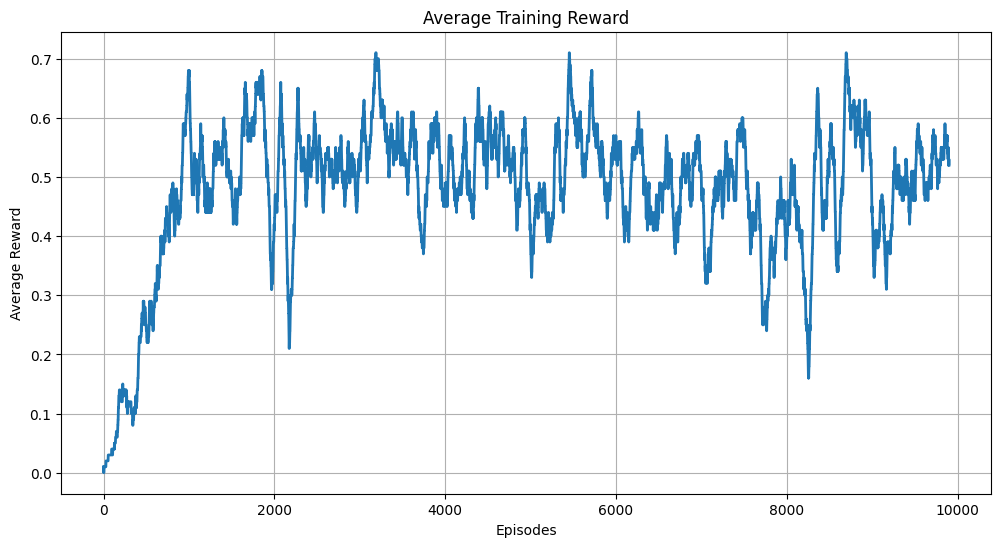

In [85]:
window = 100

moving_avg = np.convolve(
    rewards,
    np.ones(window)/window,
    mode='valid'
)

plt.figure(figsize=(12,6))

plt.plot(moving_avg, linewidth=2)

plt.title("Average Training Reward")

plt.xlabel("Episodes")

plt.ylabel("Average Reward")

plt.grid(True)

plt.show()

# Step 11: Compare Random Agent and Trained Agent

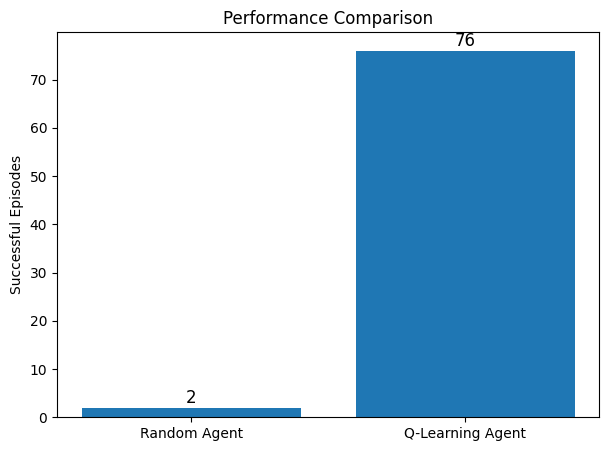

In [86]:
agents = ["Random Agent", "Q-Learning Agent"]

scores = [random_success, trained_success]

plt.figure(figsize=(7,5))

plt.bar(agents, scores)

plt.title("Performance Comparison")

plt.ylabel("Successful Episodes")

for i, value in enumerate(scores):
    plt.text(i, value + 1, str(value), ha='center', fontsize=12)

plt.show()

# Step 12: Visualize the Learned Policy

The arrows below represent the best action learned by the agent for each state.

← Left

↓ Down

→ Right

↑ Up

In [87]:
actions = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

policy = []

for state in range(env.observation_space.n):

    best_action = np.argmax(q_table[state])

    policy.append(actions[best_action])

policy = np.array(policy).reshape(4,4)

print("Learned Policy\n")

print(policy)

Learned Policy

[['←' '↑' '↑' '↑']
 ['←' '←' '→' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]


# Step 13: Display Final Results

In [88]:
print("="*50)

print("FINAL RESULTS")

print("="*50)

print("Random Agent Success :", random_success)

print("Trained Agent Success :", trained_success)

print("Improvement :", trained_success-random_success)

print("="*50)

FINAL RESULTS
Random Agent Success : 2
Trained Agent Success : 76
Improvement : 74


# Step 14: Success Rate Calculation

In [89]:
random_rate = (random_success / 100) * 100

trained_rate = (trained_success / 100) * 100

print(f"Random Agent Success Rate : {random_rate:.2f}%")

print(f"Q-Learning Agent Success Rate : {trained_rate:.2f}%")

Random Agent Success Rate : 2.00%
Q-Learning Agent Success Rate : 76.00%
